# labelling of risk category

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/train_features.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 7)


,vehicle_count,pedestrian_count,total_objects,object_density,avg_bbox_area,max_bbox_area,image_id
0,10,0,10,0.000011,5201.100000,13746,5a2419f3-4fc0d689.jpg
1,2,0,2,0.000002,160903.000000,281196,397cfb2a-77707f3d.jpg
2,1,0,1,0.000001,2200.000000,2200,740285bf-e568f563.jpg
3,8,1,9,0.000010,36140.666667,116034,59700f72-90902d09.jpg
4,4,3,7,0.000008,1706.571429,2688,afd05abf-0de7f963.jpg


In [ ]:
features = [
    "vehicle_count",
    "pedestrian_count",
    "object_density",
    "avg_bbox_area",
    "max_bbox_area"
]

X = df[features]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

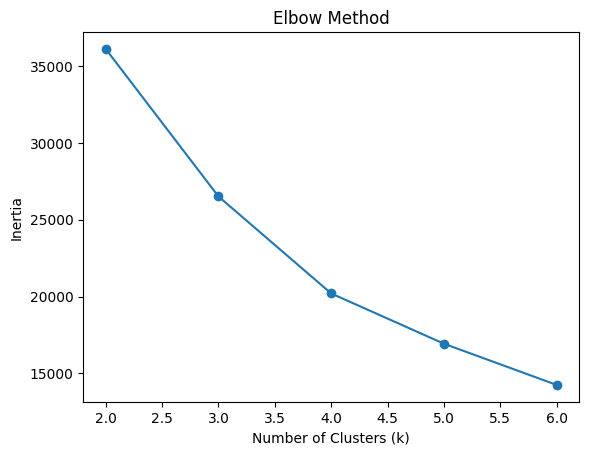

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

k_values = range(2, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, Silhouette Score={score:.4f}")

k=2, Silhouette Score=0.3620
k=3, Silhouette Score=0.4068
k=4, Silhouette Score=0.4268
k=5, Silhouette Score=0.3549
k=6, Silhouette Score=0.3660


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

df["cluster"].value_counts()

,count
cluster,
0,5764
1,3327
2,909


In [ ]:
df.groupby("cluster")[features].mean()

,vehicle_count,pedestrian_count,object_density,avg_bbox_area,max_bbox_area
cluster,,,,,
0,3.709750,0.254684,0.000004,13175.258379,32722.625434
1,11.327021,1.362489,0.000014,14341.800807,72576.028554
2,5.392739,0.489549,0.000006,83934.446717,255903.295930


In [ ]:
cluster_mapping = {
    0: "Low",
    2: "Medium",
    1: "High"
}

df["risk_label"] = df["cluster"].map(cluster_mapping)

In [ ]:
df["risk_label"].value_counts()

,count
risk_label,
Low,5764
High,3327
Medium,909


In [ ]:
output_path = "/content/drive/MyDrive/train_features_with_risk.csv"

df.to_csv(output_path, index=False)

print("✅ Dataset with risk labels saved successfully.")

✅ Dataset with risk labels saved successfully.


In [ ]:
pd.read_csv(output_path).head()

,vehicle_count,pedestrian_count,total_objects,object_density,avg_bbox_area,max_bbox_area,image_id,cluster,risk_label
0,10,0,10,0.000011,5201.100000,13746,5a2419f3-4fc0d689.jpg,1,High
1,2,0,2,0.000002,160903.000000,281196,397cfb2a-77707f3d.jpg,2,Medium
2,1,0,1,0.000001,2200.000000,2200,740285bf-e568f563.jpg,0,Low
3,8,1,9,0.000010,36140.666667,116034,59700f72-90902d09.jpg,1,High
4,4,3,7,0.000008,1706.571429,2688,afd05abf-0de7f963.jpg,0,Low


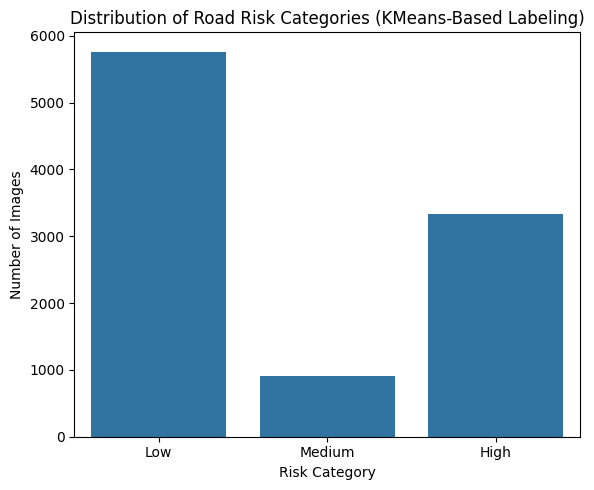

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.countplot(x="risk_label", data=df, order=["Low","Medium","High"])
plt.title("Distribution of Road Risk Categories (KMeans-Based Labeling)")
plt.xlabel("Risk Category")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

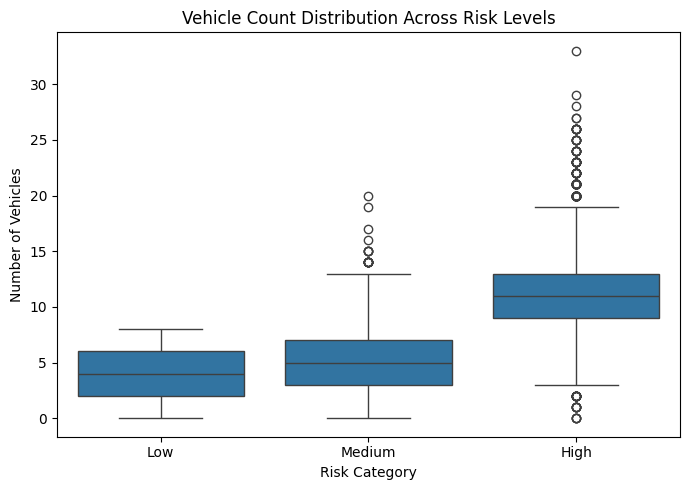

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x="risk_label", y="vehicle_count", data=df, order=["Low","Medium","High"])
plt.title("Vehicle Count Distribution Across Risk Levels")
plt.xlabel("Risk Category")
plt.ylabel("Number of Vehicles")
plt.tight_layout()
plt.show()

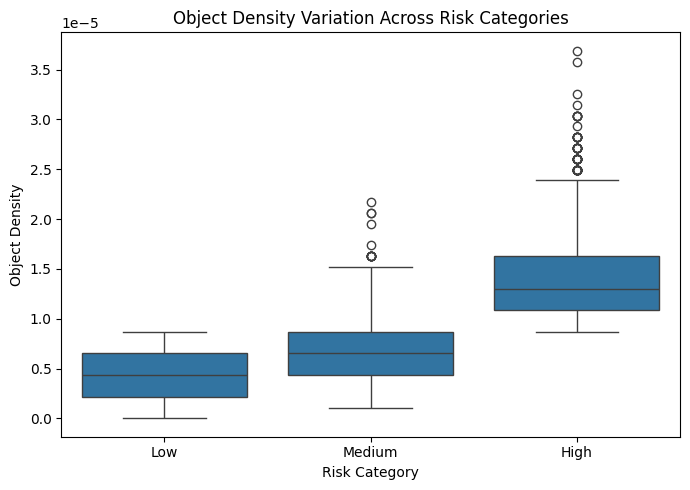

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x="risk_label", y="object_density", data=df, order=["Low","Medium","High"])
plt.title("Object Density Variation Across Risk Categories")
plt.xlabel("Risk Category")
plt.ylabel("Object Density")
plt.tight_layout()
plt.show()

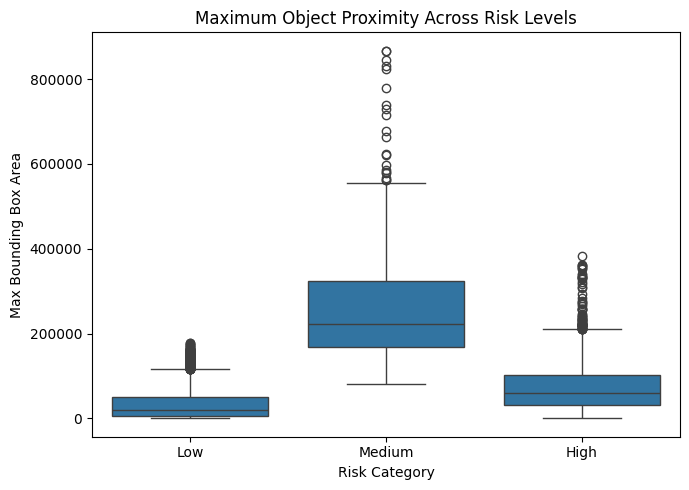

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x="risk_label", y="max_bbox_area", data=df, order=["Low","Medium","High"])
plt.title("Maximum Object Proximity Across Risk Levels")
plt.xlabel("Risk Category")
plt.ylabel("Max Bounding Box Area")
plt.tight_layout()
plt.show()

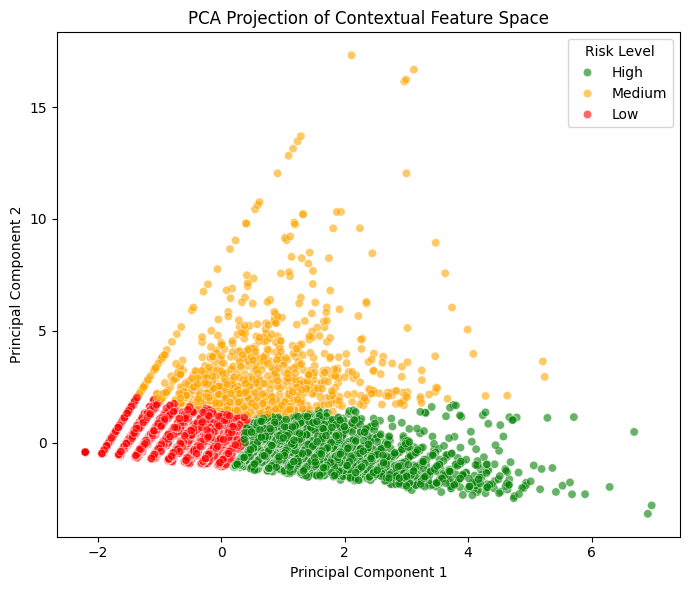

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df["risk_label"],
                palette=["green","orange","red"], alpha=0.6)
plt.title("PCA Projection of Contextual Feature Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Risk Level")
plt.tight_layout()
plt.show()

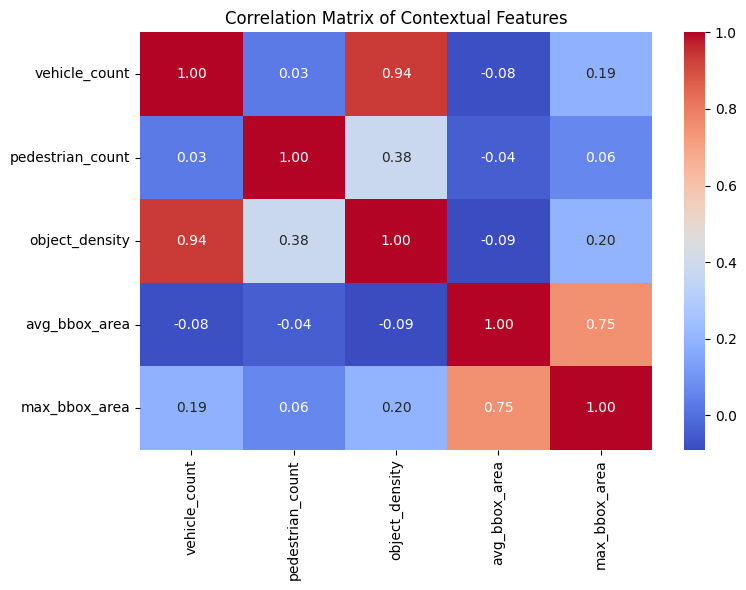

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Contextual Features")
plt.tight_layout()
plt.show()

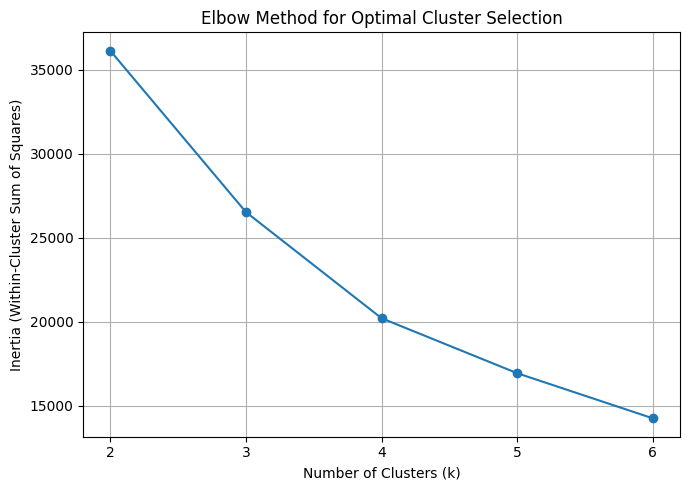

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_values = range(2, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(k_values, inertia, marker='o')
plt.title("Elbow Method for Optimal Cluster Selection")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

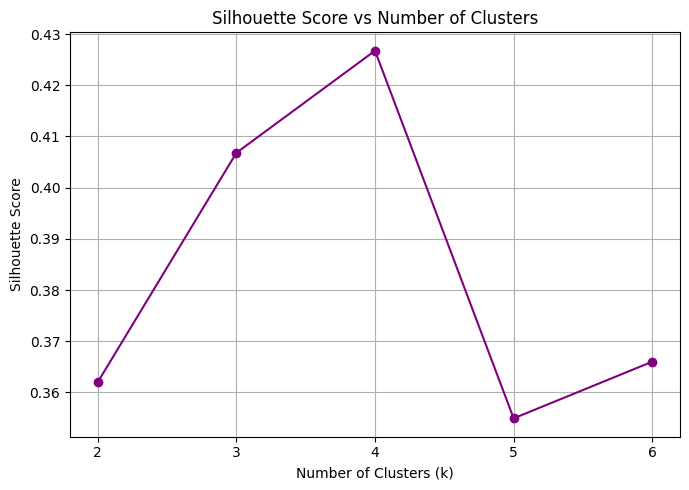

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(7,5))
plt.plot(k_values, silhouette_scores, marker='o', color='purple')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

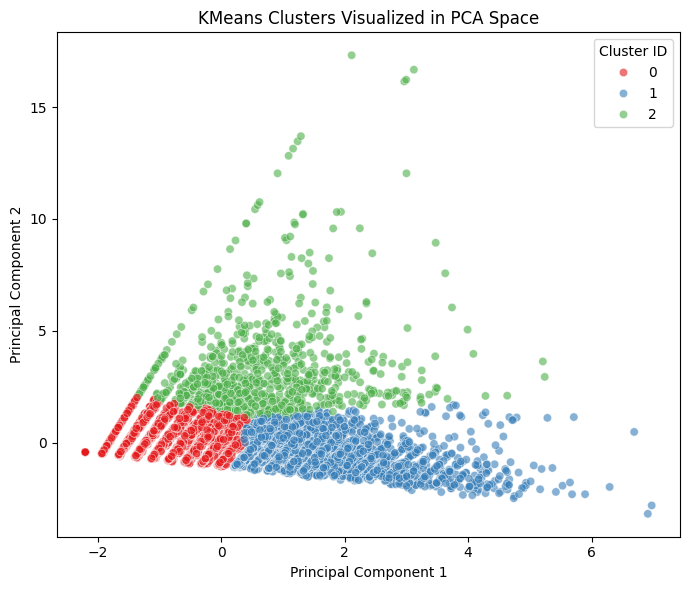

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["cluster"],
    palette="Set1",
    alpha=0.6
)

plt.title("KMeans Clusters Visualized in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster ID")
plt.tight_layout()
plt.show()

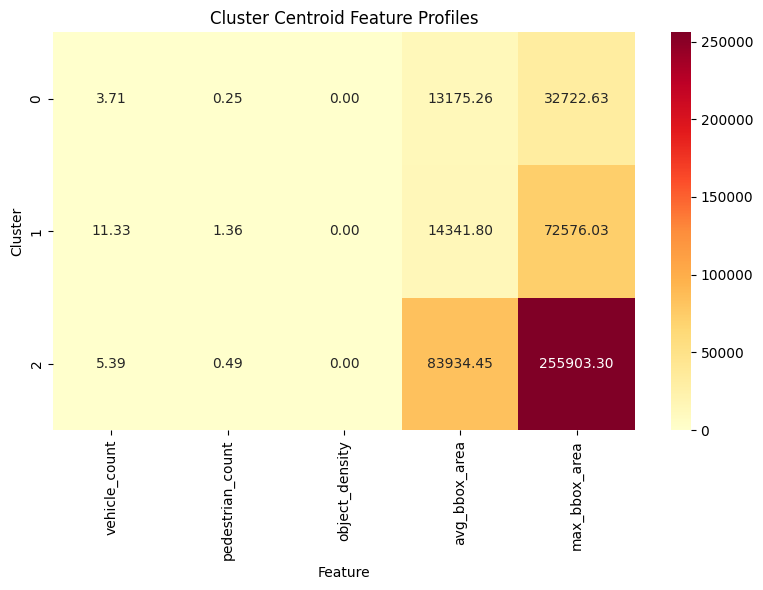

In [ ]:
cluster_means = df.groupby("cluster")[features].mean()

plt.figure(figsize=(8,6))
sns.heatmap(cluster_means, annot=True, cmap="YlOrRd", fmt=".2f")
plt.title("Cluster Centroid Feature Profiles")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()